In [2]:
import pandas as pd
import numpy as mp
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
data = pd.read_csv("../data/spam.csv", encoding="latin-1")

In [4]:
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
data = data[['v1','v2']]

In [6]:
data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
data.columns = ['label','message']

In [8]:
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
data['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [10]:
data.shape

(5572, 2)

In [11]:
data['label']=data['label'].map({'ham':0, 'spam':1})

In [12]:
data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer 

In [14]:
vectorizer = TfidfVectorizer()

In [15]:
X = vectorizer.fit_transform(data['message'])

In [16]:
y = data['label']

In [17]:
X.shape

(5572, 8672)

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state=42
)

In [19]:
X_train.shape

(4457, 8672)

In [21]:
X_test.shape

(1115, 8672)

In [22]:
from sklearn.naive_bayes import MultinomialNB

In [23]:
model = MultinomialNB()


In [24]:
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9623318385650225

In [27]:
from sklearn.metrics import confusion_matrix 
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix 

array([[965,   0],
       [ 42, 108]])

In [28]:
from sklearn.metrics import classification_report 
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



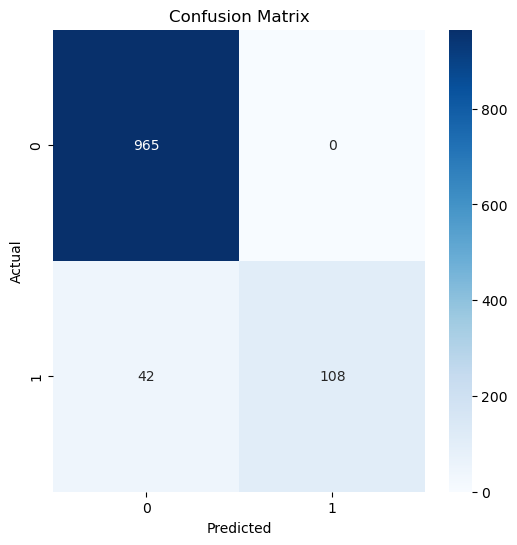

In [29]:
plt.figure(figsize=(6,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [33]:
import joblib
joblib.dump(model, "../models/naive_bayes_model.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")

['../models/vectorizer.pkl']

In [34]:
X =vectorizer.fit_transform(data['message'])
X.shape

(5572, 8672)